# DPhi - NLP Bootcamp - headline sarcastic classification
##### Dawood AL-Waqedi

## Problem Overview

#### In this challenge, you will work on a dataset that contains news headlines - which are aimed to be written in a sarcastic manner by the news author. Our job here is to build our NLP models and predict whether the headline is sarcastic or not.

### About the Data & Data Description

###### Each record of dataset consists of two attributes: 
###### is_sarcastic: 1 if the record is sarcastic otherwise 0. This is the target variable.
###### headline: this is the headline of the news article

## Loading Libraries

In [63]:
import warnings
warnings.filterwarnings('ignore')

In [64]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Loading the datasets

In [65]:
df_train = pd.read_csv('e:Train_Data.csv')
df_test = pd.read_csv('e:Test_Data.csv')

## # Target Variable:

In [66]:
df_train.is_sarcastic.value_counts()

0    23958
1    20304
Name: is_sarcastic, dtype: int64

# Input Variables & /Features:

In [67]:
df_train['headline']

0        supreme court votes 7-2 to legalize all worldl...
1        hungover man horrified to learn he made dozens...
2        emily's list founder: women are the 'problem s...
3            send your kids back to school with confidence
4                watch: experts talk pesticides and health
                               ...                        
44257     greece seeks to reassure europe as tensions rise
44258    vatican says transgender man cannot become a g...
44259    protesters ejected from donald trump rally aft...
44260          italian recipes that are oldies but goodies
44261    area loser blissfully unaffected by whims of s...
Name: headline, Length: 44262, dtype: object

## Exploratory Data Analysis (EDA) & Data Visulation

In [68]:
df_train.head()

,headline,is_sarcastic
0,supreme court votes 7-2 to legalize all worldl...,1
1,hungover man horrified to learn he made dozens...,1
2,emily's list founder: women are the 'problem s...,0
3,send your kids back to school with confidence,0
4,watch: experts talk pesticides and health,0


In [69]:
df_test.head()

,headline
0,area stand-up comedian questions the deal with...
1,dozens of glowing exit signs mercilessly taunt...
2,perfect response to heckler somewhere in prop ...
3,gop prays for ossoff lossoff
4,trevor noah says the scary truth about trump's...


In [70]:
df_train.shape

(44262, 2)

In [71]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44262 entries, 0 to 44261
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   headline      44262 non-null  object
 1   is_sarcastic  44262 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 691.7+ KB


In [72]:
df_train['is_sarcastic'].value_counts()

0    23958
1    20304
Name: is_sarcastic, dtype: int64

Not Sarcastic: 
Is Sarcastic: 


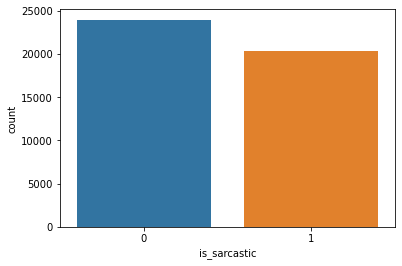

In [73]:
sns.countplot(x="is_sarcastic",data=df_train) 
print("Not Sarcastic: "%(df_train["is_sarcastic"].value_counts()[0]))
print("Is Sarcastic: "%(df_train["is_sarcastic"].value_counts()[1]))

#  Feature Engineering

In [74]:
df_train["len_Word_headline"]=df_train["headline"].apply(lambda x: len(x.split()))

In [75]:
import string

def count_punct(text):
    count = sum([1 for char in text if char in string.punctuation])
    return round( count/(len(text) - text.count(" ")),3)*100

df_train['head_len_char'] = df_train['headline'].apply(lambda x: len(x) - x.count(" "))
df_train['punct%'] = df_train['headline'].apply(lambda x: count_punct(x))

In [76]:
df_train.head()

,headline,is_sarcastic,len_Word_headline,head_len_char,punct%
0,supreme court votes 7-2 to legalize all worldl...,1,9,45,2.2
1,hungover man horrified to learn he made dozens...,1,12,55,0.0
2,emily's list founder: women are the 'problem s...,0,10,56,7.1
3,send your kids back to school with confidence,0,8,38,0.0
4,watch: experts talk pesticides and health,0,6,36,2.8


<AxesSubplot:xlabel='len_Word_headline', ylabel='Count'>

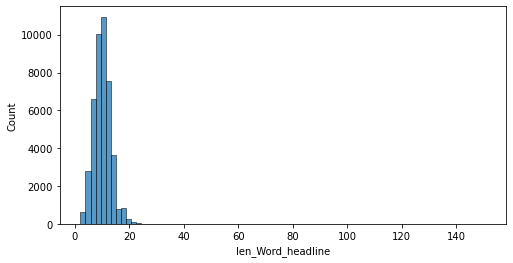

In [78]:
plt.figure(figsize=(8,4))
sns.histplot(x="len_Word_headline",data=df_train,bins=80)

<AxesSubplot:>

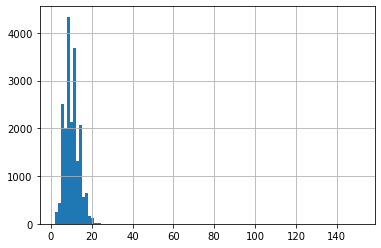

In [79]:
df_train[df_train["is_sarcastic"]==1]["len_Word_headline"].hist(bins=100)

<AxesSubplot:>

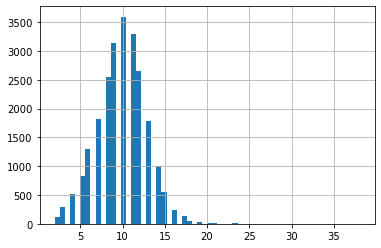

In [80]:
df_train[df_train["is_sarcastic"]==0]["len_Word_headline"].hist(bins=60)

<AxesSubplot:xlabel='punct%', ylabel='Count'>

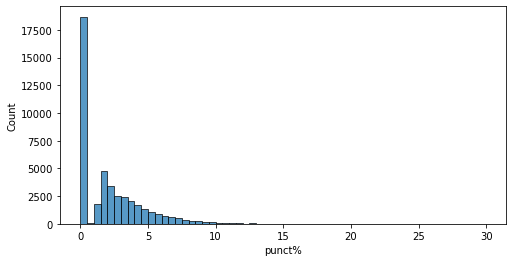

In [85]:
plt.figure(figsize=(8,4))
sns.histplot(x="punct%",data=df_train,bins=60)

<AxesSubplot:>

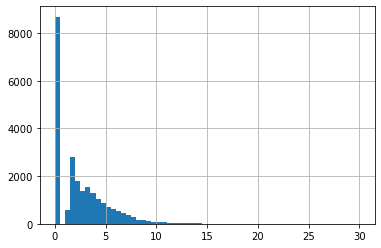

In [86]:
df_train[df_train["is_sarcastic"]==0]["punct%"].hist(bins=60)

<AxesSubplot:>

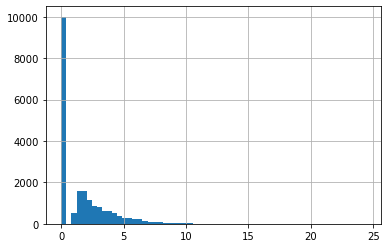

In [87]:
df_train[df_train["is_sarcastic"]==1]["punct%"].hist(bins=60)

## Pre-Processing text & Features & vectorize

In [89]:
x = df_train['headline']

In [91]:
# Create a bag of words & Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
cv = TfidfVectorizer()
d_vact = cv.fit_transform(x)

## Train and  Split data

In [92]:
from sklearn.model_selection import train_test_split

In [93]:
X = d_vact
y = df_train['is_sarcastic']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size = 0.20,random_state = 12)

## Building ML Model

In [95]:
model1 = SVC()
model1.fit(X_train, y_train)

SVC()

In [97]:
model1.score(X_test, y_test)

0.934824353326556

## Evaluate the model

In [98]:
y_pred=model1.predict(X_test)

In [99]:
y_test.values

array([0, 0, 0, ..., 1, 1, 1], dtype=int64)

In [100]:
y_pred

array([0, 0, 0, ..., 1, 1, 1], dtype=int64)

In [101]:
from sklearn.metrics import accuracy_score
print('Training accuracy...', accuracy_score(y_train, model1.predict(X_train)))
print('Test accuracy', accuracy_score(y_test,model1.predict(X_test)))

Training accuracy... 0.9945211669349601
Test accuracy 0.934824353326556


In [102]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[4490,  276],
       [ 301, 3786]], dtype=int64)

In [103]:
from sklearn.metrics import classification_report
print((classification_report(y_test,y_pred)))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      4766
           1       0.93      0.93      0.93      4087

    accuracy                           0.93      8853
   macro avg       0.93      0.93      0.93      8853
weighted avg       0.93      0.93      0.93      8853



 ## Execute this model of test_data

In [104]:
data = cv.transform(df_test['headline']).toarray()
y_pred_test = model1.predict(data)

In [105]:
y_pred_test

array([0, 1, 1, ..., 0, 1, 0], dtype=int64)

In [106]:
df = pd.DataFrame(y_pred_test, columns=['prediction'])
df.to_csv('e:y_pred_test.csv',index=False)

## thank you Dphi